# Base Paper Reproduction — Hajek et al. (2025)
**Multimodal Financial Sentiment for Stock Return Prediction**

This notebook reproduces the baseline and proposed models from the base paper, adapted to our PEAD project:
- **Task:** Regression (predict `target_return` using MSE loss)
- **Baselines:** LSTM, BiLSTM, CNN-LSTM (paper Table 4)
- **Proposed model:** Transformer encoder + dense sentiment branches + multi-head attention fusion + ticker embeddings
- **Metrics:** RMSE, MAE, DA% (matching paper's evaluation protocol)

**Adaptation notes:**
- Paper predicts 3-day CAR; we predict peak upside return in the 9-day post-earnings drift window
- Paper uses 70/30 train-test split; we use expanding-window temporal CV (5 folds) to prevent data leakage
- Paper's market sentiment (VIX, THI, SSW) is substituted with news/social sentiment scores (same concept, different source)
- DA% computed as sign agreement between predicted and actual return (matching paper exactly)

In [19]:
import polars as pl
import numpy as np
import re, os, pickle
from datetime import date

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt

pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(30)

device = torch.device("mps") if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")


def to_class(values):
    """Bin continuous returns (%-points) into 3 classes: 0 (<2%), 1 (2-4%), 2 (>4%)."""
    return np.where(values < 2.0, 0, np.where(values < 4.0, 1, 2))


Device: cpu


## 1. Data loading

In [20]:
# Technical modeling table (18 features × 12 time steps + targets)
tech_path = "../data/model_staging/tech_modeling_table.parquet"
df_tech = pl.read_parquet(tech_path)
print(f"Tech table shape: {df_tech.shape}")
print(f"Columns: {df_tech.columns[:15]}...")

Tech table shape: (24048, 225)
Columns: ['symbol', 'earnings_date', 'entry_price', 'target_return', 'target_class', 'max_high', 'min_high', 'max_day', 'min_day', 'open_pct_t-10', 'high_pct_t-10', 'low_pct_t-10', 'volume_rel_t-10', 'rsi_t-10', 'macd_t-10']...


## 2. Target distribution

The paper predicts CAR (cumulative abnormal return) as a continuous variable and derives DA% from sign agreement. 
Our target (`target_return`) measures the peak upside return in the 9-day post-earnings drift window. 
DA% is computed as sign agreement between predicted and actual values, exactly as in the paper.

In [21]:
tr = df_tech["target_return"]
print("=== target_return distribution ===")
print(f"Count:  {len(tr)}")
print(f"Mean:   {tr.mean():.4f}  ({tr.mean()*100:.2f}%)")
print(f"Std:    {tr.std():.4f}  ({tr.std()*100:.2f}%)")
print(f"Min:    {tr.min():.4f}")
print(f"Max:    {tr.max():.4f}")

tc = df_tech["target_class"]
print(f"\ntarget_class distribution (for DA%):")
print(f"  Class 0 (<2%):  {(tc == 0).sum()} ({(tc == 0).mean()*100:.1f}%)")
print(f"  Class 1 (2-4%): {(tc == 1).sum()} ({(tc == 1).mean()*100:.1f}%)")
print(f"  Class 2 (>4%):  {(tc == 2).sum()} ({(tc == 2).mean()*100:.1f}%)")

=== target_return distribution ===
Count:  24048
Mean:   0.0430  (4.30%)
Std:    0.0455  (4.55%)
Min:    -0.1315
Max:    1.1203

target_class distribution (for DA%):
  Class 0 (<2%):  7955 (33.1%)
  Class 1 (2-4%): 6428 (26.7%)
  Class 2 (>4%):  9665 (40.2%)


## 3. Multimodal data assembly

Following the paper's 3-modality structure:
1. **Technical indicators** (time-varying) — already in `df_tech`
2. **Market sentiment** — paper uses VIX, THI, SSW; we substitute news/social sentiment scores
3. **Text sentiment** — FinBERT scores from earnings call transcripts (matches paper exactly)

In [22]:
# ── Modality 3: Text sentiment (FinBERT from earnings transcripts) ──
df_finbert = pl.read_parquet("../data/model_staging/finbert_tx_agg_weighted.parquet")
df_finbert = df_finbert.select([
    "symbol", pl.col("reportedDate").alias("earnings_date"),
    "pos_prob", "neg_prob"
])
print(f"FinBERT records: {len(df_finbert)}")

# ── Modality 2: Market sentiment (news sentiment as substitute) ──
df_nz = pl.read_parquet("../data/model_staging/nz_sentiment.parquet")
df_nz = df_nz.select([
    "symbol", pl.col("reportedDate").alias("earnings_date"),
    "overall_sentiment_score_pre", "ticker_sentiment_score_pre",
    "overall_sentiment_score_post", "ticker_sentiment_score_post",
])
print(f"News sentiment records: {len(df_nz)}")

# ── Join ──
df_model = df_tech.join(df_finbert, on=["symbol", "earnings_date"], how="left")
df_model = df_model.join(df_nz, on=["symbol", "earnings_date"], how="left")

# ── Ticker ID mapping (for ticker embeddings, paper Section 3.4) ──
symbols = sorted(df_model["symbol"].unique().to_list())
sym_to_id = {s: i for i, s in enumerate(symbols)}
df_model = df_model.with_columns(
    pl.col("symbol").replace_strict(sym_to_id).cast(pl.Int64).alias("ticker_id")
)

print(f"\nFinal model table: {df_model.shape}")
print(f"Unique symbols: {len(symbols)}")

FinBERT records: 24294
News sentiment records: 24294

Final model table: (24048, 232)
Unique symbols: 503


## 4. Feature parsing by modality

Separate features into the paper's three branches:
- **Technical** (time-varying): 18 features × 12 time steps → `(N, 12, 18)` tensor for transformer/LSTM
- **Market sentiment** (static): 4 news sentiment scores → dense branch
- **Text sentiment** (static): 2 FinBERT scores → dense branch

In [23]:
exclude_cols = ["symbol", "earnings_date", "entry_price", "target_return",
                "target_class", "max_high", "min_high", "max_day", "min_day",
                "ticker_id"]

# ── Technical time-varying features ──
all_cols = [c for c in df_model.columns if c not in exclude_cols]
time_cols = sorted([c for c in all_cols if re.match(r".+_t[+-]?\d+$", c)])

# ── Market sentiment features (paper: VIX, THI, SSW → our substitute) ──
market_cols = ["overall_sentiment_score_pre", "ticker_sentiment_score_pre",
               "overall_sentiment_score_post", "ticker_sentiment_score_post"]

# ── Text sentiment features (FinBERT — matches paper) ──
text_cols = ["pos_prob", "neg_prob"]

# ── Parse time structure ──
bases = sorted(set(re.sub(r"_t[+-]?\d+$", "", c) for c in time_cols))
steps = sorted({int(re.search(r"_t([+-]?\d+)$", c).group(1)) for c in time_cols})
n_steps, n_bases = len(steps), len(bases)
n_market, n_text = len(market_cols), len(text_cols)
n_symbols = len(symbols)

# ── Index mappings for reshaping ──
step_to_idx = {s: i for i, s in enumerate(steps)}
base_to_idx = {b: i for i, b in enumerate(bases)}

# For baseline models: combined feature list
all_feature_cols = time_cols + market_cols + text_cols
col_to_idx = {c: i for i, c in enumerate(all_feature_cols)}
col_grid = np.full((n_steps, n_bases), -1, dtype=int)
for c in time_cols:
    s = int(re.search(r"_t([+-]?\d+)$", c).group(1))
    b = re.sub(r"_t[+-]?\d+$", "", c)
    col_grid[step_to_idx[s], base_to_idx[b]] = col_to_idx[c]

n_static = n_market + n_text

print(f"Time steps: {n_steps}, Technical bases: {n_bases}")
print(f"Market sentiment features: {n_market} → {market_cols}")
print(f"Text sentiment features:   {n_text} → {text_cols}")
print(f"Ticker embedding vocab:    {n_symbols}")

Time steps: 12, Technical bases: 18
Market sentiment features: 4 → ['overall_sentiment_score_pre', 'ticker_sentiment_score_pre', 'overall_sentiment_score_post', 'ticker_sentiment_score_post']
Text sentiment features:   2 → ['pos_prob', 'neg_prob']
Ticker embedding vocab:    503


## 5. Model architectures

### Baselines (paper Table 4)
LSTM, BiLSTM, CNN-LSTM — each processes concatenated multimodal input as described in the paper. 
All are **regression** models (1 output neuron, MSE loss).

### Proposed model (paper Sections 3.1–3.5)
Transformer encoder for technical features + dense branches for market/text sentiment + 
multi-head attention fusion + ticker embeddings.

In [24]:
# ══════════════════════════════════════════════════════════
#  BASELINES — LSTM, BiLSTM, CNN-LSTM (paper Table 4)
#  Process concatenated multimodal input, output 1 (regression)
# ══════════════════════════════════════════════════════════

class LSTMBaseline(nn.Module):
    def __init__(self, n_bases, n_static, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(n_bases, hidden, batch_first=True)
        self.fc = nn.Linear(hidden + n_static, 1)

    def forward(self, x_seq, x_stat, ticker_ids=None):
        _, (hn, _) = self.lstm(x_seq)
        h = hn[-1]
        if x_stat is not None and x_stat.shape[1] > 0:
            h = torch.cat([h, x_stat], dim=1)
        return self.fc(h).squeeze(-1)


class BiLSTMBaseline(nn.Module):
    def __init__(self, n_bases, n_static, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(n_bases, hidden, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden * 2 + n_static, 1)

    def forward(self, x_seq, x_stat, ticker_ids=None):
        _, (hn, _) = self.lstm(x_seq)
        h = torch.cat((hn[-2], hn[-1]), dim=1)
        if x_stat is not None and x_stat.shape[1] > 0:
            h = torch.cat([h, x_stat], dim=1)
        return self.fc(h).squeeze(-1)


class CNNLSTMBaseline(nn.Module):
    def __init__(self, n_bases, n_static, hidden=64, kernel=3):
        super().__init__()
        self.conv = nn.Conv1d(n_bases, n_bases, kernel, padding=kernel // 2)
        self.relu = nn.ReLU()
        self.lstm = nn.LSTM(n_bases, hidden, batch_first=True)
        self.fc = nn.Linear(hidden + n_static, 1)

    def forward(self, x_seq, x_stat, ticker_ids=None):
        x_seq = self.relu(self.conv(x_seq.transpose(1, 2)).transpose(1, 2))
        _, (hn, _) = self.lstm(x_seq)
        h = hn[-1]
        if x_stat is not None and x_stat.shape[1] > 0:
            h = torch.cat([h, x_stat], dim=1)
        return self.fc(h).squeeze(-1)

In [25]:
# ══════════════════════════════════════════════════════════
#  PROPOSED MODEL — paper Sections 3.1–3.5
#  Transformer + Dense sentiment + Attention fusion + Ticker embedding
# ══════════════════════════════════════════════════════════

class ProposedModel(nn.Module):
    """
    Hajek et al. (2025) multimodal architecture:
      (1) Transformer encoder for technical indicators (Sec 3.1)
      (2) Dense layers for market sentiment (Sec 3.2, Eq. 3)
      (3) Dense layers for text sentiment  (Sec 3.2, Eq. 4)
      (4) Multi-head attention fusion      (Sec 3.3, Eq. 5)
      (5) Ticker embedding gating          (Sec 3.4, Eq. 6)
      (6) Final regression layer           (Sec 3.5)
    """
    def __init__(self, n_tech, n_market, n_text, n_symbols,
                 d_model=64, n_heads=8, n_layers=2, dropout=0.2):
        super().__init__()

        # (1) Transformer encoder for technical features
        self.tech_proj = nn.Linear(n_tech, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # (2) Market sentiment branch: 2 dense layers (32 → 16) + ReLU
        self.market_branch = nn.Sequential(
            nn.Linear(n_market, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 16), nn.ReLU(), nn.Dropout(dropout),
        )
        self.market_proj = nn.Linear(16, d_model)

        # (3) Text sentiment branch: 2 dense layers (32 → 16) + ReLU
        self.text_branch = nn.Sequential(
            nn.Linear(n_text, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 16), nn.ReLU(), nn.Dropout(dropout),
        )
        self.text_proj = nn.Linear(16, d_model)

        # (4) Multi-head attention fusion (Eq. 5)
        #     Q = T_tech, K = V = [M_dense, T_dense]
        self.fusion_attn = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=n_heads,
            dropout=dropout, batch_first=True
        )
        self.fusion_dense = nn.Sequential(
            nn.Linear(d_model, d_model), nn.ReLU(), nn.Dropout(dropout)
        )

        # (5) Ticker embeddings (Eq. 6)
        self.ticker_emb = nn.Embedding(n_symbols, d_model)
        self.ticker_gate = nn.Linear(d_model, d_model)

        # (6) Final regression layer
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x_tech, x_market, x_text, ticker_ids):
        # (1) Technical branch: project → transformer → pool
        tech = self.tech_proj(x_tech)                   # (B, T, d_model)
        tech = self.transformer(tech)                    # (B, T, d_model)

        # (2) Market sentiment → dense → project to d_model
        market = self.market_branch(x_market)            # (B, 16)
        market = self.market_proj(market).unsqueeze(1)   # (B, 1, d_model)

        # (3) Text sentiment → dense → project to d_model
        text = self.text_branch(x_text)                  # (B, 16)
        text = self.text_proj(text).unsqueeze(1)         # (B, 1, d_model)

        # (4) Fusion: Q=tech, K/V=[market, text]
        kv = torch.cat([market, text], dim=1)            # (B, 2, d_model)
        fused, self._attn_w = self.fusion_attn(tech, kv, kv)  # (B, T, d_model)
        fused = fused.mean(dim=1)                        # (B, d_model)
        fused = self.fusion_dense(fused)

        # (5) Ticker embedding gating (Eq. 6: O = F ⊙ σ(W·E))
        emb = self.ticker_emb(ticker_ids)                # (B, d_model)
        gate = torch.sigmoid(self.ticker_gate(emb))      # (B, d_model)
        fused = fused * gate

        # (6) Regression output
        return self.fc(fused).squeeze(-1)                # (B,)

## 6. Training and evaluation helpers

In [26]:
def train_epoch(model, loader, opt, loss_fn, proposed=False):
    model.train()
    total_loss, n = 0, 0
    for batch in loader:
        if proposed:
            x_tech, x_mkt, x_txt, tids, y = [b.to(device) for b in batch]
            opt.zero_grad()
            pred = model(x_tech, x_mkt, x_txt, tids)
        else:
            x_seq, x_stat, y = batch
            x_seq, x_stat, y = x_seq.to(device), x_stat.to(device), y.to(device)
            opt.zero_grad()
            pred = model(x_seq, x_stat)
        loss = loss_fn(pred, y)
        loss.backward()
        opt.step()
        total_loss += loss.item() * len(y)
        n += len(y)
    return total_loss / n


def eval_model(model, loader, proposed=False):
    model.eval()
    preds_all, trues_all = [], []
    with torch.no_grad():
        for batch in loader:
            if proposed:
                x_tech, x_mkt, x_txt, tids, y = [b.to(device) for b in batch]
                pred = model(x_tech, x_mkt, x_txt, tids)
            else:
                x_seq, x_stat, y = batch
                x_seq, x_stat = x_seq.to(device), x_stat.to(device)
                pred = model(x_seq, x_stat)
            preds_all.append(pred.cpu().numpy())
            trues_all.append(y.numpy())

    preds = np.concatenate(preds_all)
    trues = np.concatenate(trues_all)
    rmse = np.sqrt(mean_squared_error(trues, preds))
    mae = mean_absolute_error(trues, preds)
    da = np.mean(to_class(preds) == to_class(trues))

    return {"preds": preds, "true": trues, "rmse": rmse, "mae": mae, "da": da}

## 7. Data preparation and preprocessing

In [27]:
# ── Temporal folds (expanding window) ──
TRAIN_WINDOW = 7
FOLDS = [
    (date(y - TRAIN_WINDOW, 1, 1), date(y, 1, 1), date(y + 1, 1, 1))
    for y in range(2021, 2026)
]


def prepare_baseline(df):
    """Prepare data for baseline models: concat all features."""
    X = df.select(all_feature_cols).to_numpy().astype(np.float32)
    X = np.where(np.isinf(X), np.nan, X)
    imp = SimpleImputer(strategy="median")
    X = imp.fit_transform(X)

    # Time-varying → (N, T, F)
    X_time = np.zeros((len(X), n_steps, n_bases), dtype=np.float32)
    for s in range(n_steps):
        for b in range(n_bases):
            idx = col_grid[s, b]
            if idx >= 0:
                X_time[:, s, b] = X[:, idx]

    # Static (market + text sentiment)
    static_idx = [col_to_idx[c] for c in market_cols + text_cols]
    X_stat = X[:, static_idx]

    sc_t = StandardScaler()
    X_time = sc_t.fit_transform(X_time.reshape(-1, n_bases)).reshape(X_time.shape)
    sc_s = StandardScaler()
    X_stat = sc_s.fit_transform(X_stat)

    return X_time, X_stat, imp, sc_t, sc_s


def transform_baseline(df, imp, sc_t, sc_s):
    """Transform test set for baselines (fit on train only)."""
    X = df.select(all_feature_cols).to_numpy().astype(np.float32)
    X = np.where(np.isinf(X), np.nan, X)
    X = imp.transform(X)

    X_time = np.zeros((len(X), n_steps, n_bases), dtype=np.float32)
    for s in range(n_steps):
        for b in range(n_bases):
            idx = col_grid[s, b]
            if idx >= 0:
                X_time[:, s, b] = X[:, idx]

    static_idx = [col_to_idx[c] for c in market_cols + text_cols]
    X_stat = X[:, static_idx]

    X_time = sc_t.transform(X_time.reshape(-1, n_bases)).reshape(X_time.shape)
    X_stat = sc_s.transform(X_stat)
    return X_time, X_stat


def prepare_proposed(df):
    """Prepare data for proposed model: separate modality branches."""
    # Technical
    Xr = df.select(time_cols).to_numpy().astype(np.float32)
    Xr = np.where(np.isinf(Xr), np.nan, Xr)
    imp_t = SimpleImputer(strategy="median"); Xr = imp_t.fit_transform(Xr)

    tc_idx = {c: i for i, c in enumerate(time_cols)}
    X_tech = np.zeros((len(Xr), n_steps, n_bases), dtype=np.float32)
    for c in time_cols:
        s = int(re.search(r"_t([+-]?\d+)$", c).group(1))
        b = re.sub(r"_t[+-]?\d+$", "", c)
        X_tech[:, step_to_idx[s], base_to_idx[b]] = Xr[:, tc_idx[c]]
    sc_tech = StandardScaler()
    X_tech = sc_tech.fit_transform(X_tech.reshape(-1, n_bases)).reshape(X_tech.shape)

    # Market sentiment
    Xm = df.select(market_cols).to_numpy().astype(np.float32)
    Xm = np.where(np.isinf(Xm), np.nan, Xm)
    imp_m = SimpleImputer(strategy="median"); Xm = imp_m.fit_transform(Xm)
    sc_m = StandardScaler(); Xm = sc_m.fit_transform(Xm)

    # Text sentiment
    Xt = df.select(text_cols).to_numpy().astype(np.float32)
    Xt = np.where(np.isinf(Xt), np.nan, Xt)
    imp_x = SimpleImputer(strategy="median"); Xt = imp_x.fit_transform(Xt)
    sc_x = StandardScaler(); Xt = sc_x.fit_transform(Xt)

    tids = df["ticker_id"].to_numpy().astype(np.int64)
    return X_tech, Xm, Xt, tids, (imp_t, imp_m, imp_x, sc_tech, sc_m, sc_x)


def transform_proposed(df, prep):
    """Transform test set for proposed model."""
    imp_t, imp_m, imp_x, sc_tech, sc_m, sc_x = prep

    Xr = df.select(time_cols).to_numpy().astype(np.float32)
    Xr = np.where(np.isinf(Xr), np.nan, Xr)
    Xr = imp_t.transform(Xr)
    tc_idx = {c: i for i, c in enumerate(time_cols)}
    X_tech = np.zeros((len(Xr), n_steps, n_bases), dtype=np.float32)
    for c in time_cols:
        s = int(re.search(r"_t([+-]?\d+)$", c).group(1))
        b = re.sub(r"_t[+-]?\d+$", "", c)
        X_tech[:, step_to_idx[s], base_to_idx[b]] = Xr[:, tc_idx[c]]
    X_tech = sc_tech.transform(X_tech.reshape(-1, n_bases)).reshape(X_tech.shape)

    Xm = df.select(market_cols).to_numpy().astype(np.float32)
    Xm = np.where(np.isinf(Xm), np.nan, Xm)
    Xm = sc_m.transform(imp_m.transform(Xm))

    Xt = df.select(text_cols).to_numpy().astype(np.float32)
    Xt = np.where(np.isinf(Xt), np.nan, Xt)
    Xt = sc_x.transform(imp_x.transform(Xt))

    tids = df["ticker_id"].to_numpy().astype(np.int64)
    return X_tech, Xm, Xt, tids

## 8. Training

Hyperparameters follow the paper (Section 5):
- Adam optimizer, lr = 5×10⁻⁴, β₁ = 0.9, β₂ = 0.999
- Dropout = 0.2
- `target_return` scaled to percentage points (×100) for loss-scale parity with the paper

In [28]:
BATCH_SIZE = 128
EPOCHS = 30
LR = 5e-4          # paper's learning rate

results = {}

# ═══════════════════════════════════════════
#  BASELINES: LSTM, BiLSTM, CNN-LSTM
# ═══════════════════════════════════════════
for ModelClass, name in [
    (LSTMBaseline, "LSTM"),
    (BiLSTMBaseline, "BiLSTM"),
    (CNNLSTMBaseline, "CNN-LSTM"),
]:
    print(f"\n{'='*55}\n{name}\n{'='*55}")
    r = {"fold_da": [], "fold_rmse": [], "fold_mae": [], "preds": [], "true": []}

    for fold_num, (tr_start, te_start, te_end) in enumerate(FOLDS, 1):
        train = df_model.filter(
            (pl.col("earnings_date") >= tr_start) & (pl.col("earnings_date") < te_start))
        test = df_model.filter(
            (pl.col("earnings_date") >= te_start) & (pl.col("earnings_date") < te_end))

        Xtr_t, Xtr_s, imp, sc_t, sc_s = prepare_baseline(train)
        Xte_t, Xte_s = transform_baseline(test, imp, sc_t, sc_s)

        # target_return × 100 → percentage points
        y_tr = train["target_return"].to_numpy().astype(np.float32) * 100
        y_te = test["target_return"].to_numpy().astype(np.float32) * 100

        train_dl = DataLoader(TensorDataset(
            torch.tensor(Xtr_t), torch.tensor(Xtr_s), torch.tensor(y_tr)),
            BATCH_SIZE, shuffle=True)
        test_dl = DataLoader(TensorDataset(
            torch.tensor(Xte_t), torch.tensor(Xte_s), torch.tensor(y_te)),
            BATCH_SIZE, shuffle=False)

        model = ModelClass(n_bases, n_static, hidden=64).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=LR, betas=(0.9, 0.999))
        loss_fn = nn.MSELoss()

        for ep in range(EPOCHS):
            train_epoch(model, train_dl, opt, loss_fn, proposed=False)

        res = eval_model(model, test_dl, proposed=False)
        r["fold_da"].append(res["da"])
        r["fold_rmse"].append(res["rmse"])
        r["fold_mae"].append(res["mae"])
        r["preds"].extend(res["preds"])
        r["true"].extend(res["true"])
        print(f"  Fold {fold_num} [{te_start.year}]: "
              f"RMSE={res['rmse']:.4f}  MAE={res['mae']:.4f}  DA={res['da']*100:.2f}%")

    results[name] = r


LSTM
  Fold 1 [2021]: RMSE=4.1275  MAE=2.8723  DA=39.90%
  Fold 2 [2022]: RMSE=5.2261  MAE=3.8450  DA=49.32%
  Fold 3 [2023]: RMSE=3.7834  MAE=2.6731  DA=39.47%
  Fold 4 [2024]: RMSE=4.5883  MAE=2.8912  DA=40.10%
  Fold 5 [2025]: RMSE=4.5195  MAE=3.0835  DA=44.07%

BiLSTM
  Fold 1 [2021]: RMSE=4.1813  MAE=2.8666  DA=37.66%
  Fold 2 [2022]: RMSE=5.0480  MAE=3.6580  DA=48.00%
  Fold 3 [2023]: RMSE=3.9322  MAE=2.7674  DA=39.06%
  Fold 4 [2024]: RMSE=4.5787  MAE=2.9263  DA=39.65%
  Fold 5 [2025]: RMSE=4.6283  MAE=3.1340  DA=41.38%

CNN-LSTM
  Fold 1 [2021]: RMSE=4.1325  MAE=2.8468  DA=39.54%
  Fold 2 [2022]: RMSE=4.6975  MAE=3.4280  DA=47.19%
  Fold 3 [2023]: RMSE=3.7405  MAE=2.6774  DA=39.57%
  Fold 4 [2024]: RMSE=4.5397  MAE=2.8677  DA=39.95%
  Fold 5 [2025]: RMSE=4.4173  MAE=3.0067  DA=43.82%


In [ ]:
# # ═══════════════════════════════════════════
# #  PROPOSED MODEL: Transformer + Fusion
# # ═══════════════════════════════════════════
# print(f"\n{'='*55}\nProposed (Transformer + Attention Fusion)\n{'='*55}")
# r = {"fold_da": [], "fold_rmse": [], "fold_mae": [], "preds": [], "true": []}

# for fold_num, (tr_start, te_start, te_end) in enumerate(FOLDS, 1):
#     train = df_model.filter(
#         (pl.col("earnings_date") >= tr_start) & (pl.col("earnings_date") < te_start))
#     test = df_model.filter(
#         (pl.col("earnings_date") >= te_start) & (pl.col("earnings_date") < te_end))

#     Xtr_tech, Xtr_mkt, Xtr_txt, tr_tids, prep = prepare_proposed(train)
#     Xte_tech, Xte_mkt, Xte_txt, te_tids = transform_proposed(test, prep)

#     y_tr = train["target_return"].to_numpy().astype(np.float32) * 100
#     y_te = test["target_return"].to_numpy().astype(np.float32) * 100

#     train_dl = DataLoader(TensorDataset(
#         torch.tensor(Xtr_tech), torch.tensor(Xtr_mkt),
#         torch.tensor(Xtr_txt), torch.tensor(tr_tids), torch.tensor(y_tr)),
#         BATCH_SIZE, shuffle=True)
#     test_dl = DataLoader(TensorDataset(
#         torch.tensor(Xte_tech), torch.tensor(Xte_mkt),
#         torch.tensor(Xte_txt), torch.tensor(te_tids), torch.tensor(y_te)),
#         BATCH_SIZE, shuffle=False)

#     model = ProposedModel(
#         n_tech=n_bases, n_market=n_market, n_text=n_text,
#         n_symbols=n_symbols, d_model=64, n_heads=8, n_layers=2, dropout=0.2
#     ).to(device)

#     opt = torch.optim.Adam(model.parameters(), lr=LR, betas=(0.9, 0.999))
#     loss_fn = nn.MSELoss()

#     for ep in range(EPOCHS):
#         train_epoch(model, train_dl, opt, loss_fn, proposed=True)

#     res = eval_model(model, test_dl, proposed=True)
#     r["fold_da"].append(res["da"])
#     r["fold_rmse"].append(res["rmse"])
#     r["fold_mae"].append(res["mae"])
#     r["preds"].extend(res["preds"])
#     r["true"].extend(res["true"])
#     print(f"  Fold {fold_num} [{te_start.year}]: "
#           f"RMSE={res['rmse']:.4f}  MAE={res['mae']:.4f}  DA={res['da']*100:.2f}%")

# results["Proposed"] = r


Proposed (Transformer + Attention Fusion)
  Fold 1 [2021]: RMSE=4.0701  MAE=2.7768  DA=41.37%


KeyboardInterrupt: 

## 9. Results summary

Compare our results with the paper's Table 4. Note: absolute RMSE/MAE values will differ because 
our target (peak drift return) differs from the paper's target (3-day CAR). The relative model 
ranking and DA% are the meaningful comparisons.

In [30]:
print("\n" + "="*70)
print("  OUR RESULTS (adapted target: peak drift return, percentage points)")
print("="*70)
print(f"{'Model':<25} {'RMSE':>8} {'MAE':>8} {'DA%':>8}")
print("-"*53)
for name, r in results.items():
    rmse = np.sqrt(mean_squared_error(r['true'], r['preds']))
    mae = mean_absolute_error(r['true'], r['preds'])
    da = np.mean(r['fold_da'])
    print(f"{name:<25} {rmse:>8.4f} {mae:>8.4f} {da*100:>7.2f}%")

print("\n" + "="*70)
print("  PAPER'S REPORTED RESULTS (Table 4: 3-day CAR, percentage points)")
print("="*70)
print(f"{'Model':<25} {'RMSE':>8} {'MAE':>8} {'DA%':>8}")
print("-"*53)
print(f"{'LSTM':<25} {'4.6610':>8} {'3.3000':>8} {'53.03%':>8}")
print(f"{'BiLSTM':<25} {'4.6390':>8} {'3.3060':>8} {'52.16%':>8}")
print(f"{'CNN-LSTM':<25} {'4.6090':>8} {'3.2760':>8} {'55.91%':>8}")
#print(f"{'Proposed':<25} {'4.6100':>8} {'3.2560':>8} {'59.94%':>8}")


  OUR RESULTS (adapted target: peak drift return, percentage points)
Model                         RMSE      MAE      DA%
-----------------------------------------------------
LSTM                        4.4753   3.0723   42.57%
BiLSTM                      4.4907   3.0702   41.15%
CNN-LSTM                    4.3192   2.9650   42.01%

  PAPER'S REPORTED RESULTS (Table 4: 3-day CAR, percentage points)
Model                         RMSE      MAE      DA%
-----------------------------------------------------
LSTM                        4.6610   3.3000   53.03%
BiLSTM                      4.6390   3.3060   52.16%
CNN-LSTM                    4.6090   3.2760   55.91%


In [32]:
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = 'white'
plt.rcParams['text.color']       = 'black'
plt.rcParams['axes.labelcolor']  = 'black'
plt.rcParams['xtick.color']      = 'black'
plt.rcParams['ytick.color']      = 'black'
plt.rcParams['axes.edgecolor']   = 'black'
plt.rcParams['grid.color']       = 'gray'

## 10. Visualizations

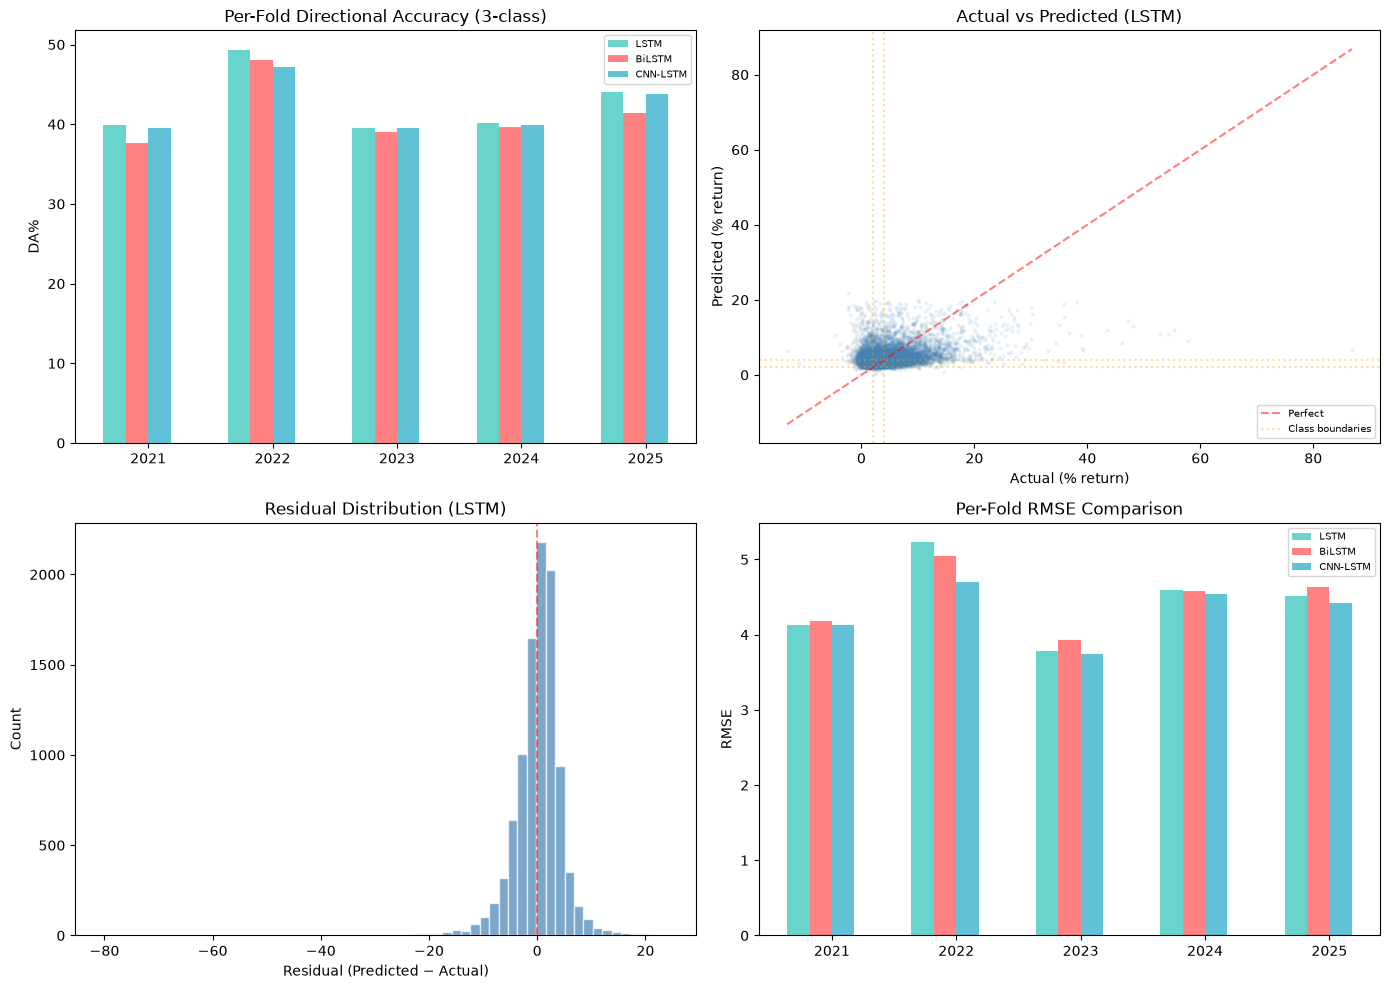

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fold_years = [2021, 2022, 2023, 2024, 2025]
x = np.arange(len(fold_years))
bw = 0.18
colors = ['#4ECDC4', '#FF6B6B', '#45B7D1', '#FFA07A']

# (a) Per-fold DA%
for i, (name, r) in enumerate(results.items()):
    axes[0,0].bar(x + i*bw, [d*100 for d in r['fold_da']], bw,
                  label=name, color=colors[i], alpha=0.85)
axes[0,0].set_xticks(x + bw*1.5)
axes[0,0].set_xticklabels(fold_years)
axes[0,0].set_ylabel('DA%')
axes[0,0].set_title('Per-Fold Directional Accuracy (3-class)')
axes[0,0].legend(fontsize=7)

# (b) Actual vs Predicted scatter (best model by DA%)
best_name = max(results, key=lambda n: np.mean(results[n]['fold_da']))
best = results[best_name]
axes[0,1].scatter(best['true'], best['preds'], alpha=0.08, s=4, color='steelblue')
lims = [min(min(best['true']), min(best['preds'])),
        max(max(best['true']), max(best['preds']))]
axes[0,1].plot(lims, lims, 'r--', alpha=0.5, label='Perfect')
axes[0,1].axhline(2.0, color='orange', ls=':', alpha=0.4)
axes[0,1].axhline(4.0, color='orange', ls=':', alpha=0.4)
axes[0,1].axvline(2.0, color='orange', ls=':', alpha=0.4, label='Class boundaries')
axes[0,1].axvline(4.0, color='orange', ls=':', alpha=0.4)
axes[0,1].set_xlabel('Actual (% return)')
axes[0,1].set_ylabel('Predicted (% return)')
axes[0,1].set_title(f'Actual vs Predicted ({best_name})')
axes[0,1].legend(fontsize=7)

# (c) Residual distribution
residuals = np.array(best['preds']) - np.array(best['true'])
axes[1,0].hist(residuals, bins=60, alpha=0.7, color='steelblue', edgecolor='white')
axes[1,0].axvline(0, color='red', ls='--', alpha=0.5)
axes[1,0].set_xlabel('Residual (Predicted − Actual)')
axes[1,0].set_ylabel('Count')
axes[1,0].set_title(f'Residual Distribution ({best_name})')

# (d) Per-fold RMSE
for i, (name, r) in enumerate(results.items()):
    axes[1,1].bar(x + i*bw, r['fold_rmse'], bw,
                  label=name, color=colors[i], alpha=0.85)
axes[1,1].set_xticks(x + bw*1.5)
axes[1,1].set_xticklabels(fold_years)
axes[1,1].set_ylabel('RMSE')
axes[1,1].set_title('Per-Fold RMSE Comparison')
axes[1,1].legend(fontsize=7)

plt.tight_layout()
plt.savefig('base_paper_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Save results

In [34]:
os.makedirs("models", exist_ok=True)
pickle.dump(results, open("models/base_paper_results.pkl", "wb"))
print("Saved: models/base_paper_results.pkl")
print(f"Keys: {list(results.keys())}")
print(f"Per-model keys: {list(results['LSTM'].keys())}")

Saved: models/base_paper_results.pkl
Keys: ['LSTM', 'BiLSTM', 'CNN-LSTM']
Per-model keys: ['fold_da', 'fold_rmse', 'fold_mae', 'preds', 'true']
